## Zadanie 1: Prosty ranking wierzchołków

Celem tej części laboratorium jest implementacja i analiza podstawowego modelu błądzenia przypadkowegona skierowanych grafach silnie spójnych.

In [28]:
import numpy as np
from numpy import linalg as LA
import time
import networkx as nx
import matplotlib.pyplot as plt

## 1. Konstrukcja kolumnowo-stochastycznej macierzy przejścia

Zgodnie z konwencją, kolumna $v$ tej macierzy koduje rozkład prawdopodobieństwa wykonania kroku z wierzchołka $v$ do jego następników.

Poniższa funkcja `build_transition_matrix` iteruje po liście sąsiedztwa i dla każdej krawędzi $(v, u) \in E$ przypisuje wartość:
$$A_{u,v} = \frac{1}{N_v}$$
gdzie $N_v$ to stopień wyjściowy węzła $v$. Dzięki temu suma prawdopodobieństw w każdej kolumnie, dla nie wiszących węzłów, wynosi dokładnie 1, co czyni macierz $A$ stochastyczną w kolumnach.

In [29]:
def build_transition_matrix(adj_list):

    n = len(adj_list)
    A = np.zeros((n, n))
    
    for u, neighbors in adj_list.items():
        out_degree = len(neighbors)
        if out_degree > 0:
            for v in neighbors:
                A[v, u] = 1.0 / out_degree
                
    return A

## 2. Implementacja metody potęgowej (Power Method)

Metoda potęgowa to iteracyjny algorytm służący do znajdowania dominującego wektora własnego macierzy $dA$. Obliczenia opierają się na relacji rekurencyjnej:
$$r_{i+1} = d A r_i$$

Gdzie:
* $r_i$ – wektor PageRank w $i$-tej iteracji.
* $d$ – współczynnik tłumienia.

Ale właśnie w tym przypadku współczynnik tłumienia $d$ nie wpływa na obliczenia, poniważ w nastepnym kroku normalizujemy wektor $r_i$ za pomocy normy $L_1$ co redukuje wpływe wektora d.

In [30]:
def power_method(adj_list, max_iter=10000, tol=1e-8, d=0.85):
    A = build_transition_matrix(adj_list)    
    n = A.shape[0]


    r = np.ones(n) / n

    history = []
    for i in range(1, max_iter + 1):
        y = d * A @ r
        
        l1_norm = np.sum(np.abs(y))
        if l1_norm > 0: 
            r_new = y / l1_norm
        
        delta = LA.norm(r - r_new, 1)
        history.append(delta)
        
        if delta < tol:
            r = r_new
            break
            
        r = r_new

    return r, i, A, history

## 3. Weryfikacja (NumPy)

Dla upewnienia się, że nasza metoda iteracyjna działa poprawnie, stosujemy weryfikację krzyżową za pomocą algebry numerycznej.

Funkcja `verify_with_numpy`:
1. Oblicza wszystkie wartości i wektory własne macierzy $A$ za pomocą `np.linalg.eig`.
2. Znajduje dominującą wartość własną najbliższą 1.0.
3. Wyodrębnia odpowiadający jej wektor własny i normalizuje go względem normy $L_1$, aby skala wyników była tożsama z metodą potęgową.

In [31]:
def verify_with_numpy(A):
    eigvals, eigvecs = LA.eig(A)
    
    dominant_idx = np.argmin(np.abs(eigvals - 1.0))
    
    dominant_vec = np.abs(np.real(eigvecs[:, dominant_idx]))
    
    dominant_vec = dominant_vec / np.sum(np.abs(dominant_vec))
    
    return dominant_vec

Wizualizacja oraz wykres

In [49]:
def test_and_visualize_graph(G_raw, graph_name, d_param=0.85):
    # Convert to a standard directed graph 
    G = nx.convert_node_labels_to_integers(G_raw)
    
    # Force strong connectivity if it's not
    if not nx.is_strongly_connected(G):
        nodes = list(G.nodes())
        n = len(nodes)
        for i in range(n):
            G.add_edge(nodes[i], nodes[(i + 1) % n])

    # Convert to adjacency list
    adj_list = nx.to_dict_of_lists(G)

    # --- 1. Run Power Method with time measurment ---
    start_pm = time.time()
    pagerank_pm, it, A_matrix, delta_history = power_method(adj_list, d=d_param)
    end_pm = time.time()

    # --- 2. Run Full Spectral Decomposition---
    pagerank_np = verify_with_numpy(A_matrix)

    # --- 3. Print Performance and Accuracy Results ---
    print(f"--- Results for {graph_name} ---")
    print(f"Power Method completed in {it} iterations")
    print(f"Power Method Time: {end_pm - start_pm:.6f}s")

    print("Top 3 Nodes Comparison:")
    top_nodes = np.argsort(pagerank_pm)[::-1][:3]
    for rank, node in enumerate(top_nodes):
        print(f"Rank {rank+1} -> Node {node:2d} | PM: {pagerank_pm[node]:.6f} | NumPy: {pagerank_np[node]:.6f}")
        
    diff = LA.norm(pagerank_pm - pagerank_np, 1)
    print(f"\nTotal L1 difference between algorithms: {diff:.2e}\n")

    # --- 4. Visualizations ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Graph topology with PageRank weights
    pos = nx.spring_layout(G, seed=42)
    node_sizes = [pagerank_pm[node] * 6000 for node in G.nodes()]
    node_colors = [pagerank_pm[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, 
                            cmap=plt.cm.Blues, alpha=0.9, ax=ax1)
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=15, 
                            edge_color="gray", alpha=0.5, ax=ax1)
    nx.draw_networkx_labels(G, pos, font_size=10, font_color="black", font_weight="bold", ax=ax1)

    ax1.set_title(f"{graph_name} Topology (Node size ~ PageRank)", fontsize=12)
    ax1.axis("off")

    # Plot 2: Convergence curve in semi-log scale
    ax2.plot(range(1, len(delta_history) + 1), delta_history, 'o-', color='indigo', linewidth=2, label="Actual convergence")

    ax2.set_yscale('log')

    ax2.set_xlabel("Iteration", fontsize=11)
    ax2.set_ylabel("Delta in Log Scale", fontsize=11)
    ax2.set_title(f"Convergence Curve ({graph_name}, d = {d_param})", fontsize=12)
    ax2.grid(True, which="both", linestyle="--", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

## 4. Eksperymenty i interpretacja wyników

Algorytm został przetestowany na zestawach grafów o różnej topologii (gdzie $|V| > 10$), którym sztucznie wymuszono silną spójność:
1. **Erdős-Rényi** – model grafu losowego o stosunkowo jednorodnym rozkładzie stopni wierzchołków.
2. **Scale-Free** – graf bezskalowy, symulujący realną strukturę sieci WWW.
3. **Cykl ze strunami** – regularna struktura z dodanymi "skrótami", demonstrująca zaburzenie lokalnej symetrii w grafie.

Wyniki dla Erdős-Rényi

--- Results for Erdős-Rényi ---
Power Method completed in 29 iterations
Power Method Time: 0.000311s
Top 3 Nodes Comparison:
Rank 1 -> Node  9 | PM: 0.131393 | NumPy: 0.131393
Rank 2 -> Node  2 | PM: 0.100108 | NumPy: 0.100108
Rank 3 -> Node  5 | PM: 0.092674 | NumPy: 0.092674

Total L1 difference between algorithms: 4.21e-09



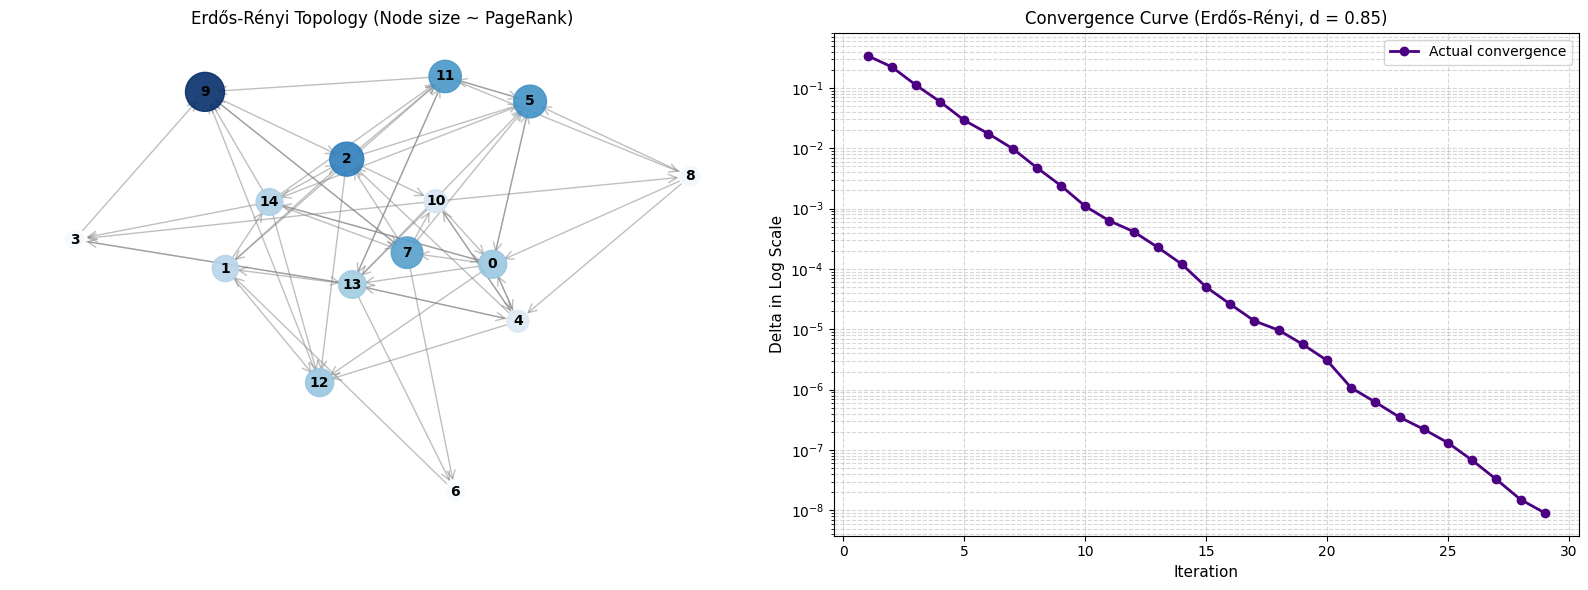

In [50]:
num_nodes = 15

G_erdos = nx.erdos_renyi_graph(n=num_nodes, p=0.25, directed=True)
test_and_visualize_graph(G_erdos, "Erdős-Rényi", )

Wyniki dla Scale-Free

--- Results for Scale-Free ---
Power Method completed in 58 iterations
Power Method Time: 0.000475s
Top 3 Nodes Comparison:
Rank 1 -> Node  1 | PM: 0.272324 | NumPy: 0.272324
Rank 2 -> Node  0 | PM: 0.270075 | NumPy: 0.270075
Rank 3 -> Node  2 | PM: 0.221457 | NumPy: 0.221457

Total L1 difference between algorithms: 2.33e-08



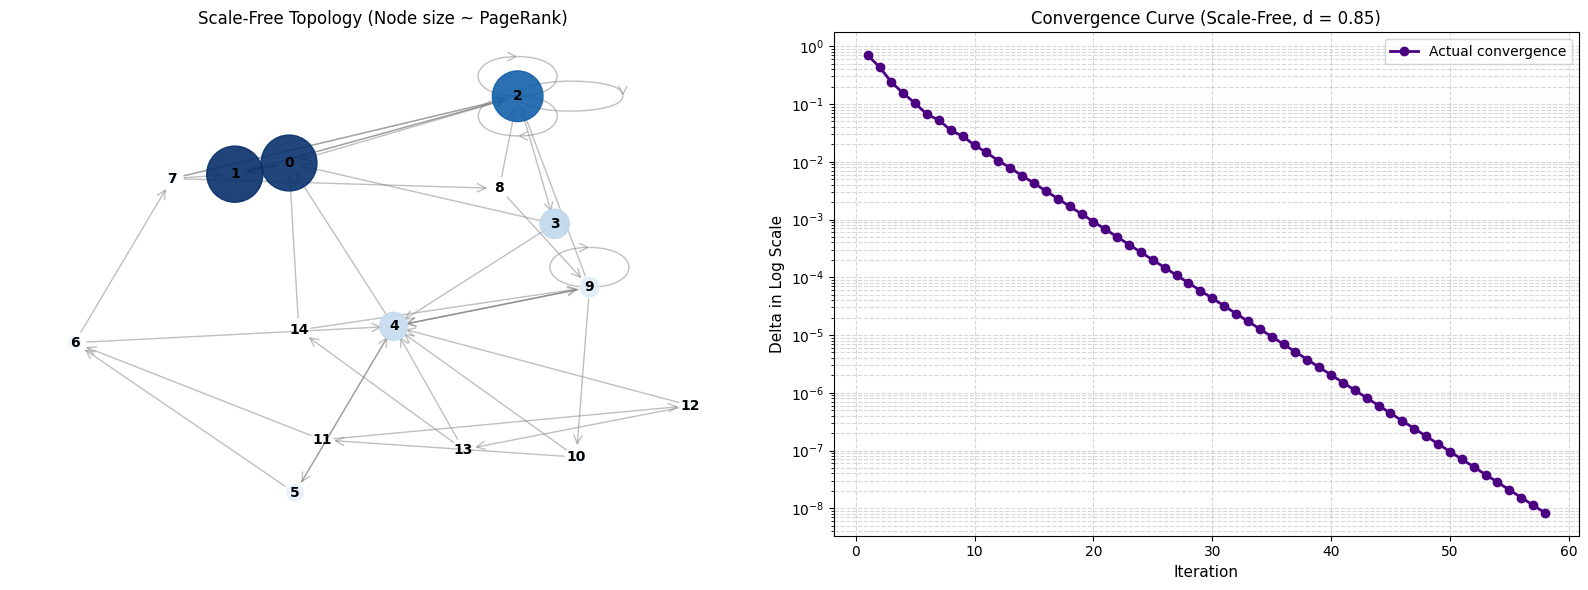

In [51]:
G_scale = nx.scale_free_graph(n=num_nodes)
test_and_visualize_graph(G_scale, "Scale-Free")

Wyniki dla Cycle with Chords

--- Results for Cycle with Chords ---
Power Method completed in 161 iterations
Power Method Time: 0.001036s
Top 3 Nodes Comparison:
Rank 1 -> Node  5 | PM: 0.109890 | NumPy: 0.109890
Rank 2 -> Node  6 | PM: 0.109890 | NumPy: 0.109890
Rank 3 -> Node  7 | PM: 0.109890 | NumPy: 0.109890

Total L1 difference between algorithms: 1.30e-08



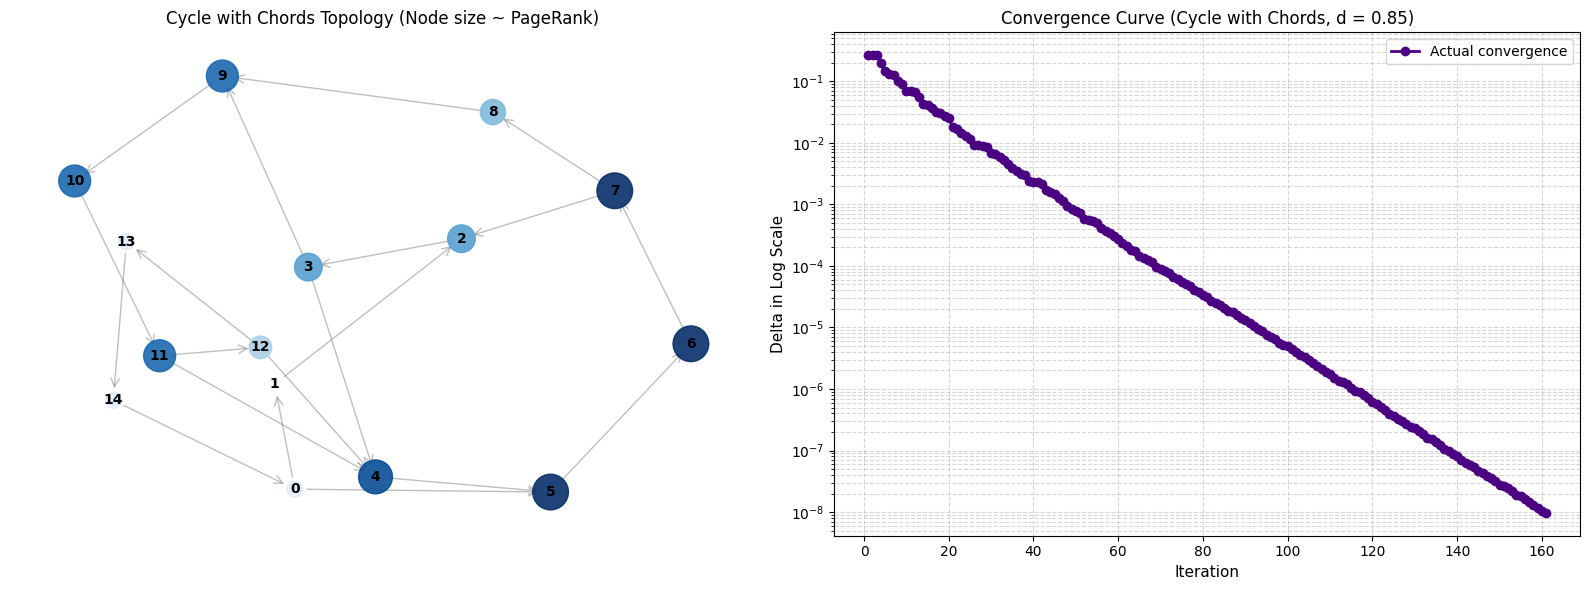

In [52]:
G_cycle_chords = nx.cycle_graph(n=num_nodes, create_using=nx.DiGraph)
extra_chords = [(0, 5), (3, 9), (7, 2), (12, 4), (11, 4), (7, 8)]
G_cycle_chords.add_edges_from(extra_chords)

test_and_visualize_graph(G_cycle_chords, "Cycle with Chords")

### Analiza wykresów:
* **Grafika struktury:** Rozmiar wierzchołków został zmapowany proporcjonalnie do ich wartości PageRank. 
* **Krzywa zbieżności:** Błąd bezwzględny $\delta = ||r_{i+1} - r_i||_1$ został przedstawiony w skali półlogarytmicznej w funkcji liczby iteracji. Obserwowany liniowy spadek na tym wykresie potwierdza wykładnicze tempo zbieżności algorytmu, co jest zgodne z matematyczną teorią łańcuchów Markowa i założeniami metody potęgowej.